In [1]:
# This environment requires PYTHON 3.11 (for gensim, no support in later version - for Word2VEC)
# In order to rerun this in python 3.11 (if you are currently in 3.14 or later)

# in terminal
# conda create -n lfbigdata python=3.11 -y
# conda activate lfbigdata
# conda install -c conda-forge gensim pandas statsmodels scikit-learn matplotlib -y
# python -m ipykernel install --user --name lfbigdata --display-name "Python 3.11 (lfbigdata)

# then change kernel to Python 3.11 (lfbigdata)

In [2]:
# Unsupervised Learning: Latent Dirichlet Allocation (LDA)
# Using LDA (latent dirichlet allocation) to find topics, and apply OLS regression with topics as IV towards our DV, S&PReact

# First we import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

# I will be using scikit, as it is easier for me due to previous python and extensive scikit usage rather than R.
from sklearn.feature_extraction.text import CountVectorizer

# LDA found on Scikit's modules.
from sklearn.decomposition import LatentDirichletAllocation


# First we import the slightly pre-processed speech dataset, that we already did couple with our DV
speeches_raw = pd.read_csv("fed_speeches_clean.csv")

# Creates the document term matrix that will be passed to the LDA function
# Vectorizer is our word-counting tool, to allow the document term matrix to be created and passed to the LDA
# Rather than using data->assignment_1->stopword packages of semantic and short, I will be using CountVectorizer from scikit
# -learn's stop_word.
# We want to only keep words that appear in minimum 10 speeches, and throw away words that appear in more than .8 (80%) of sp
# - eeches
vectorizer = CountVectorizer(stop_words="english", min_df=10, max_df=0.8)

# we then run the tool on our text speeches, cleaning and building the vocabulary ,to produce the document term matrix
dtm = vectorizer.fit_transform(speeches_raw["text"])
# now we extract the list of words that made it into the vocabulary, so we can label the word by topic later
words = vectorizer.get_feature_names_out()

# LDA parameters
seed = 2 # for reproducibility
k = 10 # amt topics

# Now we create the LDA model using variational inference, preferable to Gibbs because python workaround (as seen in tutorail)
# is slow because python natively forces each iteration to update variables (and on this large corpus it is not efficient)
# becuase we want the model to work fastest, we use all cpus with n_jobs=-1
# if we want to tune the model (via hyperparameters), max_iter is one option (as well with k of course)
model_lda = LatentDirichletAllocation(n_components=k, random_state=seed, max_iter=50, n_jobs=-1)
model_lda.fit(dtm)

# posterior probabilities per document by topic
# first we fetch the probabilities per document by topic by transforming the document term matrix and calling that the posteriors
posteriors_lda = model_lda.transform(dtm)

# small sanity check to see if our speeches still exist and each have 10 columns for the k=10
print(posteriors_lda.shape)
# also again checking a single speech's topic probabilities
# borrowed this from stackoverflow to avoid scientific notation when printing our posteriors for one specific speech
np.set_printoptions(suppress=True)
print(posteriors_lda[500, :],) 

# for each topic in range(k=10 as we set it), find and print its most defining words for us to check that the LDA is working
# as posteriors give us speeches x topics, component provides topics x words, how much each word is tied to each topic.
# here we view the table, 10 rows for topics, and columns per word 
# We then with argsort, sort each topic's words from strongest to weakest and keep only top 10, so we can inspect the topics
for topic in range(k):
    top = np.argsort(-model_lda.components_[topic])[:10]
    print(topic, [words[i] for i in top])

# Now we move onto using our posteriors from the LDA to actually predict our DV, the S&PReact
# First we need to make our posteriors into a dataframe, including the topics

df_posteriors = pd.DataFrame(posteriors_lda, columns=["topic_1", "topic_2", "topic_3", "topic_4", "topic_5",
                                                  "topic_6", "topic_7", "topic_8", "topic_9", "topic_10"])

# we then add our DV from the initial dataset into our dataframe with the topic posteriors
df_posteriors["SPREACT"] = speeches_raw["S&PREACT"].values


# Before we run regression, we define our independent variables as X
# avoiding multicollinearity by not including topic_10
X = df_posteriors[["topic_1", "topic_2", "topic_3", "topic_4", "topic_5", "topic_6", "topic_7", "topic_8", "topic_9"]]
X = sm.add_constant(X) # adding the intercept term the regression needs

# defining our target, DV
y = df_posteriors["SPREACT"]


# Running the regression and visualizing results of OLS

model_LDA_OLS = sm.OLS(y, X).fit()
print(model_LDA_OLS.summary())

(1433, 10)
[0.00006856 0.159544   0.00006856 0.03950222 0.05430751 0.00006856
 0.05328288 0.00006856 0.01912667 0.67396248]
0 ['firms', 'capital', 'crisis', 'liquidity', 'banks', 'stress', 'regulatory', 'institutions', 'regulation', 'stability']
1 ['income', 'work', 'development', 'education', 'people', 'community', 'workers', 'research', 'percent', 'communities']
2 ['growth', 'inflation', 'rate', 'percent', 'prices', 'productivity', 'labor', 'year', 'demand', 'past']
3 ['risk', 'management', 'information', 'business', 'risks', 'internal', 'corporate', 'accounting', 'controls', 'process']
4 ['countries', 'states', 'united', 'economies', 'world', 'capital', 'global', 'international', 'foreign', 'trade']
5 ['credit', 'risk', 'asset', 'securities', 'term', 'debt', 'banks', 'liquidity', 'funds', 'rates']
6 ['payments', 'services', 'payment', 'banks', 'technology', 'systems', 'industry', 'electronic', 'bank', 'security']
7 ['banks', 'risk', 'banking', 'bank', 'capital', 'basel', 'supervisor

In [3]:
# Part 2 of using LDA // this part strips speeches to maximum of 1 per day

# Unsupervised Learning: Latent Dirichlet Allocation (LDA)
# Using LDA (latent dirichlet allocation) to find topics, and apply OLS regression with topics as IV towards our DV, S&PReact

# First we import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

# I will be using scikit, as it is easier for me due to previous python and extensive scikit usage rather than R.
from sklearn.feature_extraction.text import CountVectorizer

# LDA found on Scikit's modules.
from sklearn.decomposition import LatentDirichletAllocation


# First we import the slightly pre-processed speech dataset, that we already did couple with our DV
speeches_raw = pd.read_csv("fed_speeches_clean.csv")

# Restricting speeches to 1 per date to allow regressiion to learn on single speech paired with S&Preact and not multiple on same DV.
speeches_raw = speeches_raw.drop_duplicates(subset="speech_date")


# Creates the document term matrix that will be passed to the LDA function
# Vectorizer is our word-counting tool, to allow the document term matrix to be created and passed to the LDA
# Rather than using data->assignment_1->stopword packages of semantic and short, I will be using CountVectorizer from scikit
# -learn's stop_word.
# We want to only keep words that appear in minimum 10 speeches, and throw away words that appear in more than .8 (80%) of sp
# - eeches
vectorizer = CountVectorizer(stop_words="english", min_df=10, max_df=0.8)

# we then run the tool on our text speeches, cleaning and building the vocabulary ,to produce the document term matrix
dtm = vectorizer.fit_transform(speeches_raw["text"])
# now we extract the list of words that made it into the vocabulary, so we can label the word by topic later
words = vectorizer.get_feature_names_out()

# LDA parameters
seed = 2 # for reproducibility
k = 10 # amt topics

# Now we create the LDA model using variational inference, preferable to Gibbs because python workaround (as seen in tutorail)
# is slow because python natively forces each iteration to update variables (and on this large corpus it is not efficient)
# becuase we want the model to work fastest, we use all cpus with n_jobs=-1
# if we want to tune the model (via hyperparameters), max_iter is one option (as well with k of course)
model_lda = LatentDirichletAllocation(n_components=k, random_state=seed, max_iter=50, n_jobs=-1)
model_lda.fit(dtm)

# posterior probabilities per document by topic
# first we fetch the probabilities per document by topic by transforming the document term matrix and calling that the posteriors
posteriors_lda = model_lda.transform(dtm)

# small sanity check to see if our speeches still exist and each have 10 columns for the k=10
print(posteriors_lda.shape)
# also again checking a single speech's topic probabilities
# borrowed this from stackoverflow to avoid scientific notation when printing our posteriors for one specific speech
np.set_printoptions(suppress=True)
print(posteriors_lda[500, :],) 

# for each topic in range(k=10 as we set it), find and print its most defining words for us to check that the LDA is working
# as posteriors give us speeches x topics, component provides topics x words, how much each word is tied to each topic.
# here we view the table, 10 rows for topics, and columns per word 
# We then with argsort, sort each topic's words from strongest to weakest and keep only top 10, so we can inspect the topics
for topic in range(k):
    top = np.argsort(-model_lda.components_[topic])[:10]
    print(topic, [words[i] for i in top])

# Now we move onto using our posteriors from the LDA to actually predict our DV, the S&PReact
# First we need to make our posteriors into a dataframe, including the topics

df_posteriors = pd.DataFrame(posteriors_lda, columns=["topic_1", "topic_2", "topic_3", "topic_4", "topic_5",
                                                  "topic_6", "topic_7", "topic_8", "topic_9", "topic_10"])

# we then add our DV from the initial dataset into our dataframe with the topic posteriors
df_posteriors["SPREACT"] = speeches_raw["S&PREACT"].values


# Before we run regression, we define our independent variables as X
# avoiding multicollinearity by not including topic_10
X = df_posteriors[["topic_1", "topic_2", "topic_3", "topic_4", "topic_5", "topic_6", "topic_7", "topic_8", "topic_9"]]
X = sm.add_constant(X) # adding the intercept term the regression needs

# defining our target, DV
y = df_posteriors["SPREACT"]


# Running the regression and visualizing results

model_LDA_OLS = sm.OLS(y, X).fit()
print(model_LDA_OLS.summary())

(1225, 10)
[0.00005034 0.45523917 0.10774201 0.00005034 0.00005034 0.17431975
 0.0299051  0.00005034 0.00005034 0.23254228]
0 ['liquidity', 'credit', 'risk', 'crisis', 'institutions', 'banks', 'securities', 'term', 'assets', 'asset']
1 ['capital', 'banks', 'basel', 'risk', 'regulatory', 'firms', 'requirements', 'banking', 'stress', 'ii']
2 ['banks', 'bank', 'banking', 'institutions', 'risk', 'activities', 'insurance', 'industry', 'supervision', 'regulatory']
3 ['payments', 'work', 'services', 'public', 'payment', 'information', 'technology', 'systems', 'people', 'world']
4 ['countries', 'united', 'economies', 'states', 'capital', 'global', 'foreign', 'international', 'domestic', 'trade']
5 ['risk', 'management', 'risks', 'information', 'internal', 'credit', 'business', 'corporate', 'accounting', 'practices']
6 ['inflation', 'policy', 'monetary', 'rate', 'prices', 'price', 'rates', 'central', 'growth', 'expectations']
7 ['policy', 'rate', 'monetary', 'term', 'inflation', 'fomc', 'rates'

Average R2 k 3 -0.004875851531189079
Average R2 k 5 -0.008058012710471862
Average R2 k 10 -0.018892383772947486
Average R2 k 15 -0.024094926947752414
Average R2 k 20 -0.036816376333215925
Average R2 k 50 -0.09505670951546441


/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768

Average R2 k 100 -0.21744974693967195


/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768943056.py:46: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y_train, X_train).fit()
/var/folders/rz/gwy8zx294dl29h4fr15q1x6m0000gn/T/ipykernel_98957/768

Average R2 k 200 -0.702001807326905


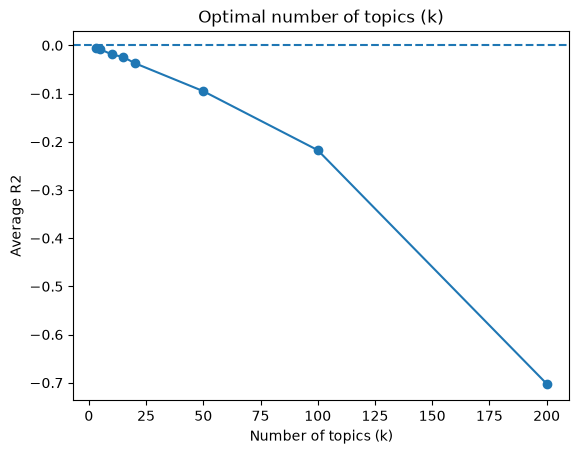

In [9]:
# Here we attempt to find the optimal K-(topic) through crossvalidation 5fold

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# the numbers of topics we want to try
k_options = [3, 5, 10, 15, 20, 50, 100, 200]

# this will hold the average R-squared for each k
all_scores = []

# our target variable
y_values = speeches_raw["S&PREACT"].values

# try each k one at a time
for k in k_options:

    # fisrt we run model with this K
    lda_model = LatentDirichletAllocation(n_components=k, random_state=2, max_iter=50, n_jobs=-1)
    topics = lda_model.fit_transform(dtm)

    # drop the last topic column (avoids the dummy trap)
    last_column = k - 1
    topics = topics[:, 0:last_column]

    # set up 5-fold cross validation
    kf = KFold(n_splits=5, shuffle=True, random_state=2)

    # this will hold the R2 from each of the 5 folds
    fold_scores = []

    # go through each fold
    for train_rows, test_rows in kf.split(topics):

        X_train = topics[train_rows]
        X_test = topics[test_rows]
        y_train = y_values[train_rows]
        y_test = y_values[test_rows]

        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test, has_constant="add")

        model = sm.OLS(y_train, X_train).fit()
        predictions = model.predict(X_test)

        score = r2_score(y_test, predictions)   # out-of-sample R2 for this fold
        fold_scores.append(score)

    # average the 5 fold scores
    total = 0
    for s in fold_scores:
        total = total + s
    average_score = total / len(fold_scores)

    print("Average R2 k", k, average_score)


    all_scores.append(average_score)


#Now we use matplotlib to plot number of topics X average R2 on out-of-sample test

plt.plot(k_options, all_scores, marker="o")
plt.title("Optimal number of topics (k)")
plt.xlabel("Number of topics (k)")
plt.ylabel("Average R2")
plt.axhline(0, linestyle="--")  # we add this line to present that if under, model is worse than just guessing mean.
plt.show()

In [5]:
# Unsupervised learning: Word2Vec  -- CBOW (skip-gram below)
# This model utilizies the datafile that EXCLUDES the same-day multiple speeches (to not mess with prediction power)

from gensim.models import Word2Vec
import hashlib

# Here we reuse the same tokenizer style as the CountVectorizer above for LDA, but iwhtout removing stopwords
# Word2vec needs the small glue words since it needs to learn the meaning from the words neighbors.
# using build analyzer to turn tokenize into a function we can use later
tokenize = CountVectorizer(stop_words=None).build_analyzer()

# now we build a loop to tokenize every single speech
# first we create the empty list to allow each speech to be stored after it is tokenized
# then we create a for loop to first tokenize each speech in speeches_raw, and then after 
# append it to our empty list, all_words    to store each tokenized speech in its own list, stored in all_words
all_words = []
for t in speeches_raw["text"]:
    all_words.append(tokenize(t))

# Now since the speeches are already chronologically ordered, there is no reason to do this in code.
# INstead, we split the speeches into two, to train on one and test on the other
# The reason we want chronological is to avoid data leakage (letting model see future).
# So first, we split all words into two.
# We then define each half into our variables, train and test speeches.
half = len(all_words) // 2
train_speeches = all_words[:half]
test_speeches  = all_words[half:]

# defining how many vectors each word should have. this is also the most important hyperparameter for model tuning.
dimensions_word2vec = 150


# Train the model (CBOW) on the older half of speeches
model_CBOW = Word2Vec(
    sentences=train_speeches,
    vector_size=dimensions_word2vec,
    sg=0,            # cbow first, we will try other one next 
    epochs=20,       #
    min_count=5,
    window=5,
    workers=1,       # setting workers to 1 should force reproducability
    seed=2,          # same seed style as random_state 
)

# Small check to see if CBOW is actually learning properly with dimensions = 10 and if words are related.
print("Here are the vectors for the word 'inflation'")
print(model_CBOW.wv["inflation"])
print("And here are the most similar vectors to inflation - this is all just to test if CBOW actually succeeded in its training")
print("The score given is the proximity in vector space; 1.00 is identical and 0.94 would be very close.")
print(model_CBOW.wv.most_similar("inflation"))


# Now we already trained the model the word's vectors, but we need vectors for each speech to use them for regression
# towards our DV

# First we define our function; it takes a list of words from one speech
def speech_vector(words):
    
    # we then create an empty list to store a speech's vectors (well vectors for each word in the speech)
    vecs = []
    
    # go through every word in this speech
    for w in words:
        if w in model_CBOW.wv:          # only use words the model actually learned, removing rare words
            vecs.append(model_CBOW.wv[w]) # this then adds (if word was in cbow.wv) the word's vectors to the vecs list
    

    if len(vecs) > 0: # if we find atleast 1 words' vectors in a speech,
        return np.mean(vecs, axis=0) # we return the mean vecs for all these words and give the speech 10 vectors.
    else:
        return np.full(dimensions_word2vec, np.nan)   # in case the speech just doesnt have any vectors, the vectors for this
                                                        # speech are just NaN


# Turns the speeches in test half into 10-number summary vector, using the speech vector function, and stacks all of those
# into one table, speeches on rows, one per speech, and the vectors on columns.
posteriors_w2v = np.array([speech_vector(s) for s in test_speeches])




# Although we built our posteriors, we need to label the columns to use them for regression
w2v_cols = [] # First design the list for the loop to store
for i in range(dimensions_word2vec): # Then run the loop, for i in our range of our 10 dimensions, 10 columns
    name = "w2v_" + str(i + 1) # name of column
    w2v_cols.append(name) # and we then append whatever is stored in name (above) and add it


# then we create the dataframe needed to run regression, as we need to (just like LDA) couple both 
# the posteriors, columns and our DV in one to run regression.
df_w2v = pd.DataFrame(posteriors_w2v, columns=w2v_cols)
df_w2v["SPREACT"] = speeches_raw["S&PREACT"].values[half:]
# just in case there are empty values we drop em.
df_w2v = df_w2v.dropna()

# Define X, add constant, define Y
X = df_w2v[w2v_cols]
X = sm.add_constant(X)
y = df_w2v["SPREACT"]

# Train model and print summary.
model_W2V_OLS = sm.OLS(y, X).fit()
print(model_W2V_OLS.summary())

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Here are the vectors for the word 'inflation'
[-1.3983454   2.688795    3.8228955   0.17256199  1.6471816  -1.239423
 -0.86213917 -2.8536355  -1.7769886   0.39530128  1.5794282   4.417447
  3.010898   -1.4678464   0.00573675  0.96859956  1.7854966  -0.15033457
 -4.0751467   3.7475731   2.1591258  -2.7423217  -0.21202973 -0.86663
 -0.6984211   0.02282879 -3.1948645   1.1414574  -0.23519732  0.73391825
 -1.2996364   0.43493766  0.2897478   2.9642944   2.1558065   0.07404348
 -2.636516    1.1104087   0.895085   -2.5850995   0.8675074  -2.1405418
 -1.2079703   1.8752314  -0.48518273  1.0434636   1.8348879   3.948279
  4.6208377  -1.1079577  -3.363458   -1.1489271  -2.779102    0.23639359
  1.0513916  -3.273027    1.4368387  -0.90167296  1.1361439  -1.3478386
  0.18717898 -0.09557857  1.3175018   0.48154223 -2.0159028   2.5863764
  0.09403838 -0.9259212  -1.774428   -1.5412781   3.6282725   0.7388065
 -4.153875   -3.161568   -0.86443365  3.3986058   0.83481586 -1.7442223
 -2.2968018   1.129

In [6]:
# Unsupervised learning: Word2Vec skip-gram
# This model utilizies the datafile that EXCLUDES the same-day multiple speeches (to not mess with prediction power)



from gensim.models import Word2Vec
import hashlib

# Here we reuse the same tokenizer style as the CountVectorizer above for LDA, but iwhtout removing stopwords
# Word2vec needs the small glue words since it needs to learn the meaning from the words neighbors.
# using build analyzer to turn tokenize into a function we can use later
tokenize = CountVectorizer(stop_words=None).build_analyzer()

# now we build a loop to tokenize every single speech
# first we create the empty list to allow each speech to be stored after it is tokenized
# then we create a for loop to first tokenize each speech in speeches_raw, and then after 
# append it to our empty list, all_words    to store each tokenized speech in its own list, stored in all_words
all_words = []
for t in speeches_raw["text"]:
    all_words.append(tokenize(t))

# Now since the speeches are already chronologically ordered, there is no reason to do this in code.
# INstead, we split the speeches into two, to train on one and test on the other
# The reason we want chronological is to avoid data leakage (letting model see future).
# So first, we split all words into two.
# We then define each half into our variables, train and test speeches.
half = len(all_words) // 2
train_speeches = all_words[:half]
test_speeches  = all_words[half:]

# defining how many vectors each word should have. this is also the most important hyperparameter for model tuning.
dimensions_word2vec = 150


# Train the model (CBOW) on the older half of speeches
model_SG = Word2Vec(
    sentences=train_speeches,
    vector_size=dimensions_word2vec,
    sg=1,            # now this is just a ctrl c of above version but here we try skip-gram
    epochs=20,       #
    min_count=5,
    window=5,
    workers=1,       # setting workers to 1 should force reproducability
    seed=2,          # same seed style as random_state 
)

# Small check to see if CBOW is actually learning properly with dimensions = 10 and if words are related.
print("Here are the vectors for the word 'inflation'")
print(model_SG.wv["inflation"])
print("And here are the most similar vectors to inflation - this is all just to test if CBOW actually succeeded in its training")
print("The score given is the similarity; 1.00 is identical and 0.94 would be very close (as of how CBOW has understood it)")
print(model_SG.wv.most_similar("inflation"))


# Now we already trained the model the word's vectors, but we need vectors for each speech to use them for regression
# towards our DV

# First we define our function; it takes a list of words from one speech
def speech_vector(words):
    
    # we then create an empty list to store a speech's vectors (well vectors for each word in the speech)
    vecs = []
    
    # go through every word in this speech
    for w in words:
        if w in model_SG.wv:          # only use words the model actually learned, removing rare words
            vecs.append(model_SG.wv[w]) # this then adds (if word was in cbow.wv) the word's vectors to the vecs list
    

    if len(vecs) > 0: # if we find atleast 1 words' vectors in a speech,
        return np.mean(vecs, axis=0) # we return the mean vecs for all these words and give the speech 10 vectors.
    else:
        return np.full(dimensions_word2vec, np.nan)   # in case the speech just doesnt have any vectors, the vectors for this
                                                        # speech are just NaN


# Turns the speeches in test half into 10-number summary vector, using the speech vector function, and stacks all of those
# into one table, speeches on rows, one per speech, and the vectors on columns.
posteriors_w2v = np.array([speech_vector(s) for s in test_speeches])




# Although we built our posteriors, we need to label the columns to use them for regression
w2v_cols = [] # First design the list for the loop to store
for i in range(dimensions_word2vec): # Then run the loop, for i in our range of our 10 dimensions, 10 columns
    name = "w2v_" + str(i + 1) # name of column
    w2v_cols.append(name) # and we then append whatever is stored in name (above) and add it


# then we create the dataframe needed to run regression, as we need to (just like LDA) couple both 
# the posteriors, columns and our DV in one to run regression.
df_w2v = pd.DataFrame(posteriors_w2v, columns=w2v_cols)
df_w2v["SPREACT"] = speeches_raw["S&PREACT"].values[half:]
# just in case there are empty values we drop em.
df_w2v = df_w2v.dropna()

# Define X, add constant, define Y
X = df_w2v[w2v_cols]
X = sm.add_constant(X)
y = df_w2v["SPREACT"]

# Train model and print summary.
model_W2V_OLS = sm.OLS(y, X).fit()
print(model_W2V_OLS.summary())

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Here are the vectors for the word 'inflation'
[ 0.08977412  0.37136164  0.3483317   0.3333785  -0.0469391  -0.2735129
 -0.23013741 -0.4265542  -0.65826774  0.07940007  0.19933923  0.07454974
  0.12744354 -0.18163002 -0.09943773 -0.15760902  0.23617497 -0.13397299
 -0.5380594   0.00944532  0.04112482  0.12368669 -0.36258262 -0.5672664
  0.35528955  0.2052359  -0.48064914 -0.10449548  0.36154723  0.2786156
  0.04679535  0.38511604 -0.01334039  0.29105392  0.05234886  0.15947483
 -0.44013038  0.12829748  0.5770703  -0.13400769 -0.29823962 -0.44124678
 -0.23520507 -0.08983605  0.05870138  0.35451642  0.28069586  0.3486179
  0.03154385 -0.5601028  -0.24612632  0.44985804 -0.18592489  0.08140364
  0.21967499 -0.01886063 -0.26713383  0.2557462   0.15486063 -0.32242125
 -0.19612437 -0.28163344  0.44704187 -0.2209536  -0.4462136   0.3779822
  0.06018324  0.15413703 -0.5693524  -0.03591572  0.00050541 -0.32087055
 -0.6347253   0.14398183 -0.07546799  0.21843372  0.4043021  -0.56079274
 -0.047335